Path: C:\ColonyNet\data\dsb2018\instances\1a11552569160f0b1ea10bedbd628ce6c14f29edec5092034c2309c556df833e.png
Shape: (1024, 1024)
Dtype: uint16
Min/Max: 0 46
Unique labels (incl. 0): 47
Non-zero labels: 46


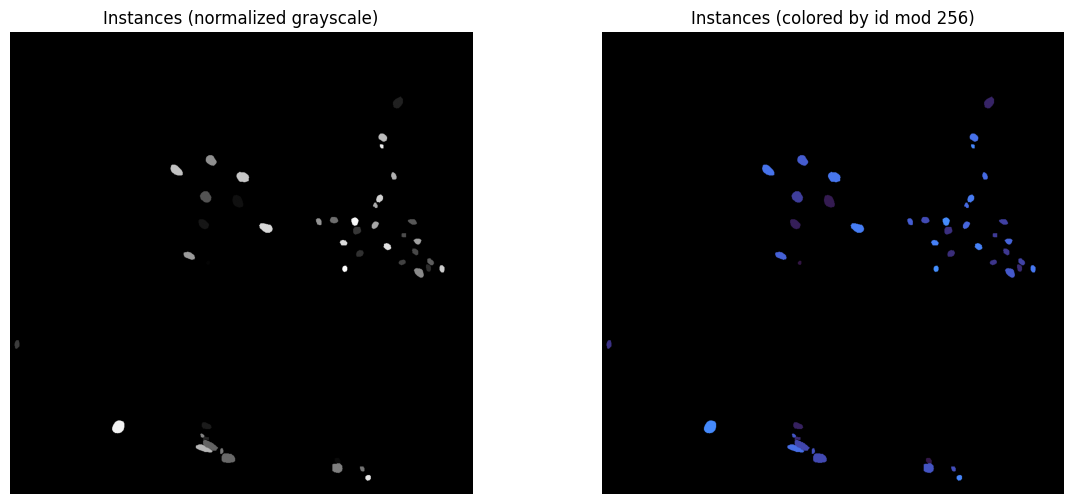

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

path = r"C:\ColonyNet\data\dsb2018\instances\1a11552569160f0b1ea10bedbd628ce6c14f29edec5092034c2309c556df833e.png"

# Read as-is (keeps uint16)
m = cv2.imread(path, cv2.IMREAD_UNCHANGED)
if m is None:
    raise FileNotFoundError(path)

print("Path:", path)
print("Shape:", m.shape)
print("Dtype:", m.dtype)
print("Min/Max:", int(m.min()), int(m.max()))
print("Unique labels (incl. 0):", int(np.unique(m).size))
print("Non-zero labels:", int(np.unique(m[m>0]).size))

# For visualization:
# 1) normalized grayscale 0..255
m_float = m.astype(np.float32)
m_norm = (m_float / (m_float.max() + 1e-6) * 255.0).astype(np.uint8)

# 2) colored label map (each instance id -> color)
#    OpenCV applyColorMap expects 8-bit, so we first compress ids to 0..255 via modulo,
#    and keep 0 as black. This is only for viewing.
m_mod = (m % 256).astype(np.uint8)
m_color = cv2.applyColorMap(m_mod, cv2.COLORMAP_TURBO)
m_color[m == 0] = (0, 0, 0)  # background black

# Plot
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.title("Instances (normalized grayscale)")
plt.imshow(m_norm, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Instances (colored by id mod 256)")
plt.imshow(cv2.cvtColor(m_color, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [1]:
import numpy as np

p = r"C:\ColonyNet\sartorius\0a6ecc5fe78a.npz"

z = np.load(p, allow_pickle=True)
print("keys:", list(z.keys()))
for k in z.files:
    a = z[k]
    print(f"{k:>12} | type={type(a)} | shape={getattr(a,'shape',None)} | dtype={getattr(a,'dtype',None)}")


keys: ['arr_0']
       arr_0 | type=<class 'numpy.ndarray'> | shape=(520, 704) | dtype=uint8


In [2]:
import numpy as np

p = r"C:\ColonyNet\sartorius\0a6ecc5fe78a.npz"
m = np.load(p, allow_pickle=True)["arr_0"]

print("dtype:", m.dtype, "shape:", m.shape)
u = np.unique(m)
print("unique:", len(u), "min/max:", int(u.min()), int(u.max()))
print("nonzero labels:", len(np.unique(m[m>0])))


dtype: uint8 shape: (520, 704)
unique: 90 min/max: 0 89
nonzero labels: 89
